# MNIST Exploratory Data Analysis

Comprehensive EDA of the MNIST handwritten digit dataset.
See `README.md` for detailed explanations of each technique and full citations.

In [3]:
%pip install umap-learn

  Using cached umap_learn-0.5.11-py3-none-any.whl.metadata (26 kB)
  Using cached pynndescent-0.6.0-py3-none-any.whl.metadata (6.9 kB)
Using cached umap_learn-0.5.11-py3-none-any.whl (90 kB)
Using cached pynndescent-0.6.0-py3-none-any.whl (73 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [umap-learn]
Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torchvision import datasets, transforms
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# Project root (same pattern as experimentation notebooks)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
data_root = os.path.join(PROJECT_ROOT, "data")

# Load raw MNIST (keep 28x28 for image analysis)
train_dataset = datasets.MNIST(root=data_root, train=True, download=True, transform=transforms.ToTensor())
test_dataset = datasets.MNIST(root=data_root, train=False, download=True, transform=transforms.ToTensor())

# Extract all data into numpy arrays for convenience
train_images = train_dataset.data.numpy()    # (60000, 28, 28) uint8
train_labels = train_dataset.targets.numpy()  # (60000,)
test_images = test_dataset.data.numpy()       # (10000, 28, 28)
test_labels = test_dataset.targets.numpy()    # (10000,)

# Flattened + normalized version for dimensionality reduction
train_flat = train_images.reshape(-1, 784).astype(np.float32) / 255.0
test_flat = test_images.reshape(-1, 784).astype(np.float32) / 255.0

print(f"Train: {train_images.shape}, Test: {test_images.shape}")
print(f"Labels: {np.unique(train_labels)}")
print(f"Dtype: {train_images.dtype}, Range: [{train_images.min()}, {train_images.max()}]")

Train: (60000, 28, 28), Test: (10000, 28, 28)
Labels: [0 1 2 3 4 5 6 7 8 9]
Dtype: uint8, Range: [0, 255]


## 1. Dataset Overview

In [5]:
print("=== Dataset Overview ===")
print(f"Training set:  {train_images.shape[0]:,} images, shape {train_images.shape[1:]}")
print(f"Test set:      {test_images.shape[0]:,} images, shape {test_images.shape[1:]}")
print(f"Total:         {train_images.shape[0] + test_images.shape[0]:,} images")
print(f"Image size:    {train_images.shape[1]}x{train_images.shape[2]} = {train_images.shape[1] * train_images.shape[2]} pixels")
print(f"Pixel dtype:   {train_images.dtype}")
print(f"Pixel range:   [{train_images.min()}, {train_images.max()}]")
print(f"Num classes:   {len(np.unique(train_labels))}")
print()

print("=== Samples Per Class (Train) ===")
for digit in range(10):
    count = (train_labels == digit).sum()
    print(f"  Digit {digit}: {count:,}")

=== Dataset Overview ===
Training set:  60,000 images, shape (28, 28)
Test set:      10,000 images, shape (28, 28)
Total:         70,000 images
Image size:    28x28 = 784 pixels
Pixel dtype:   uint8
Pixel range:   [0, 255]
Num classes:   10

=== Samples Per Class (Train) ===
  Digit 0: 5,923
  Digit 1: 6,742
  Digit 2: 5,958
  Digit 3: 6,131
  Digit 4: 5,842
  Digit 5: 5,421
  Digit 6: 5,918
  Digit 7: 6,265
  Digit 8: 5,851
  Digit 9: 5,949


## 2. Sample Visualization Grid

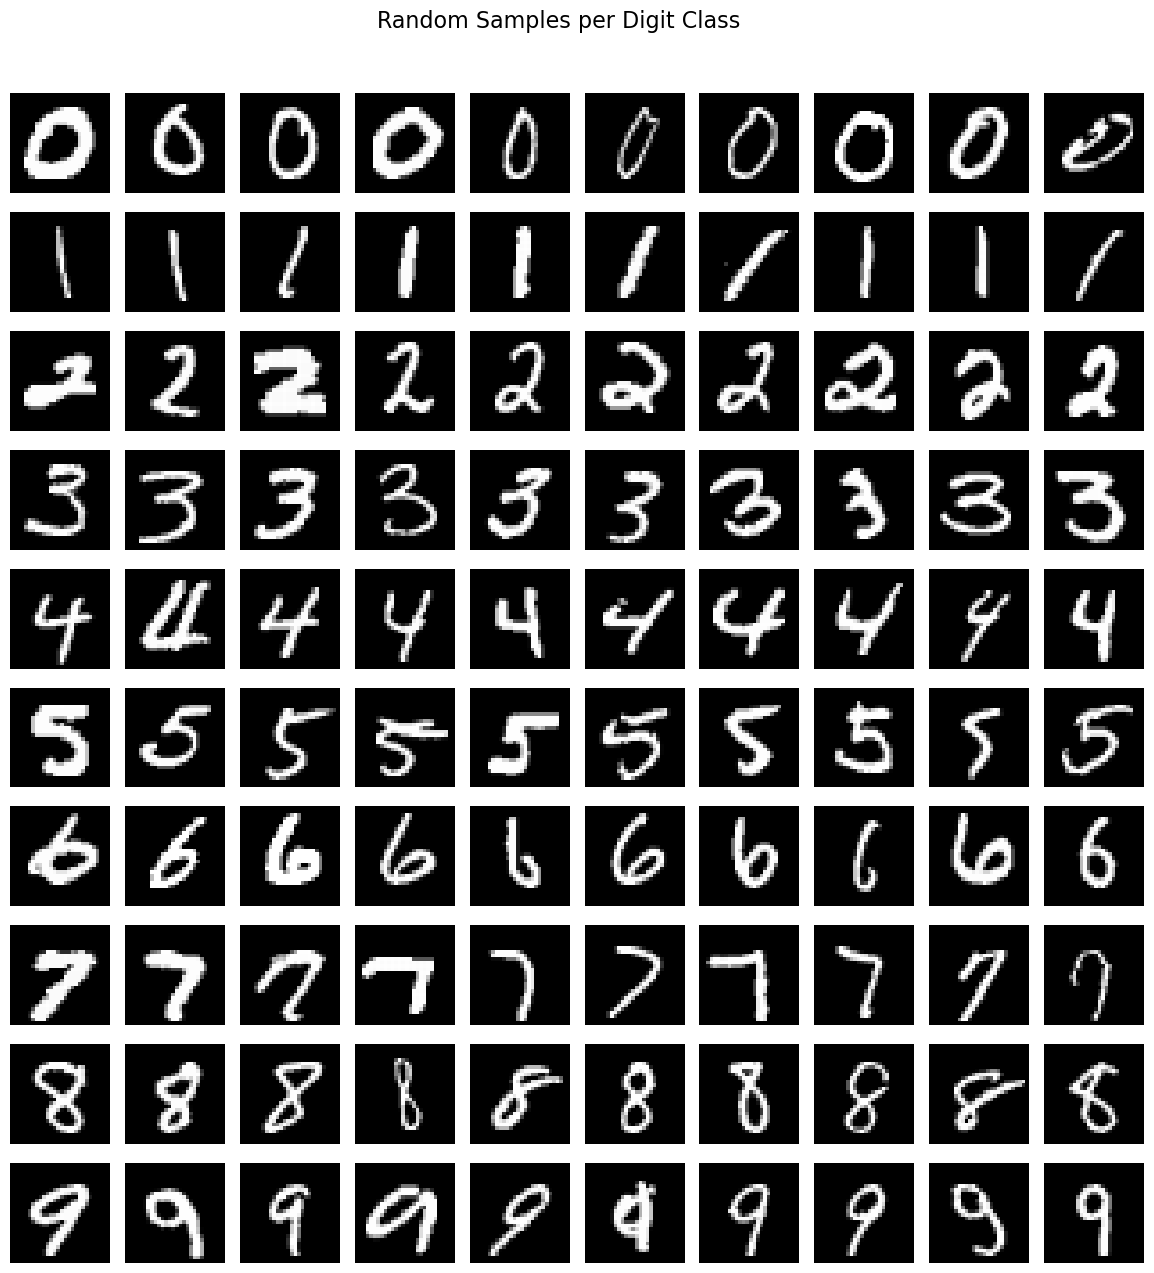

In [6]:
n_cols = 10
fig, axes = plt.subplots(10, n_cols, figsize=(12, 13))

rng = np.random.RandomState(42)

for digit in range(10):
    indices = np.where(train_labels == digit)[0]
    chosen = rng.choice(indices, size=n_cols, replace=False)
    for col, idx in enumerate(chosen):
        axes[digit, col].imshow(train_images[idx], cmap="gray")
        axes[digit, col].axis("off")
    axes[digit, 0].set_ylabel(str(digit), fontsize=14, rotation=0, labelpad=20, va="center")
    axes[digit, 0].yaxis.set_visible(True)
    axes[digit, 0].tick_params(left=False, labelleft=False)

fig.suptitle("Random Samples per Digit Class", fontsize=16, y=0.98)
plt.tight_layout(rect=[0.03, 0, 1, 0.96])
plt.show()

## 3. Class Distribution

Train class counts: min=5421, max=6742, max/min ratio=1.24


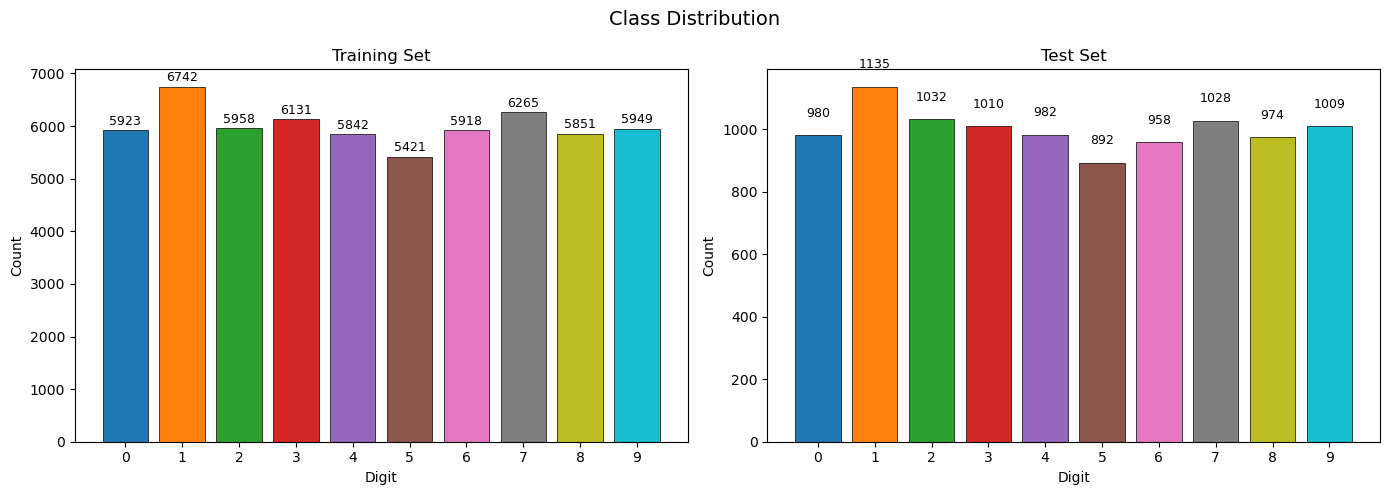

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, labels, title in [
    (axes[0], train_labels, "Training Set"),
    (axes[1], test_labels, "Test Set"),
]:
    counts = [np.sum(labels == d) for d in range(10)]
    bars = ax.bar(range(10), counts, color=plt.cm.tab10(np.arange(10)), edgecolor="black", linewidth=0.5)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                str(count), ha="center", va="bottom", fontsize=9)
    ax.set_xlabel("Digit")
    ax.set_ylabel("Count")
    ax.set_title(title)
    ax.set_xticks(range(10))

# Imbalance metrics
train_counts = [np.sum(train_labels == d) for d in range(10)]
ratio = max(train_counts) / min(train_counts)
print(f"Train class counts: min={min(train_counts)}, max={max(train_counts)}, max/min ratio={ratio:.2f}")

fig.suptitle("Class Distribution", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Pixel Intensity Analysis

Sparsity: 80.9% of all pixels are exactly 0
Global mean: 33.32, Global std: 78.57


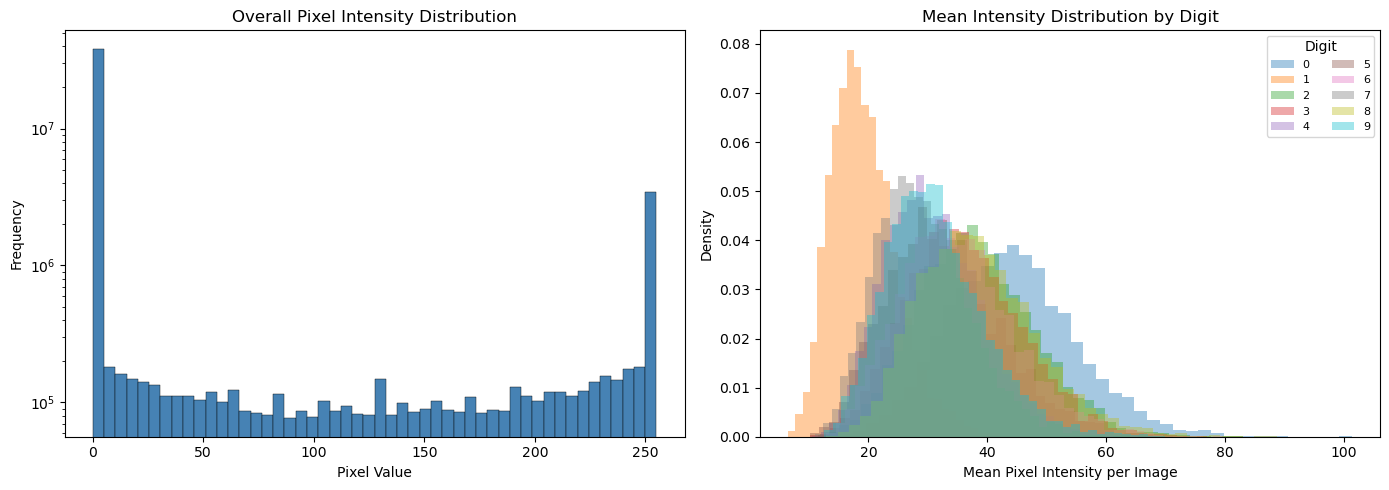

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall histogram
axes[0].hist(train_images.ravel(), bins=50, color="steelblue", edgecolor="black", linewidth=0.3)
axes[0].set_xlabel("Pixel Value")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Overall Pixel Intensity Distribution")
axes[0].set_yscale("log")

# Per-class KDE of mean pixel intensity per image
for digit in range(10):
    mask = train_labels == digit
    mean_intensities = train_images[mask].reshape(-1, 784).mean(axis=1)
    axes[1].hist(mean_intensities, bins=40, alpha=0.4, label=str(digit), density=True)

axes[1].set_xlabel("Mean Pixel Intensity per Image")
axes[1].set_ylabel("Density")
axes[1].set_title("Mean Intensity Distribution by Digit")
axes[1].legend(title="Digit", fontsize=8, ncol=2)

# Sparsity
sparsity = (train_images == 0).sum() / train_images.size * 100
print(f"Sparsity: {sparsity:.1f}% of all pixels are exactly 0")
print(f"Global mean: {train_images.mean():.2f}, Global std: {train_images.std():.2f}")

plt.tight_layout()
plt.show()

## 5. Mean and Standard Deviation Images

Dataset-wide pixel mean: 33.32
Dataset-wide pixel std:  78.57


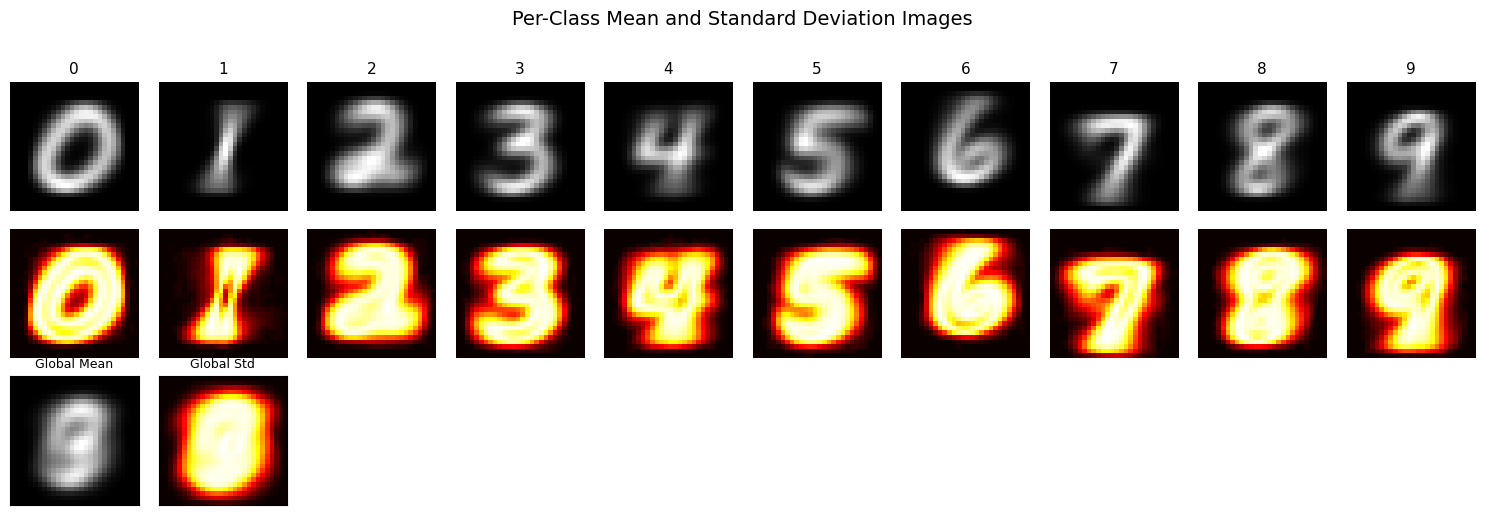

In [9]:
# Per-class mean and std images
fig, axes = plt.subplots(3, 10, figsize=(15, 5))

train_float = train_images.astype(np.float32)

for digit in range(10):
    mask = train_labels == digit
    class_images = train_float[mask]
    mean_img = class_images.mean(axis=0)
    std_img = class_images.std(axis=0)

    axes[0, digit].imshow(mean_img, cmap="gray")
    axes[0, digit].set_title(str(digit), fontsize=11)
    axes[0, digit].axis("off")

    axes[1, digit].imshow(std_img, cmap="hot")
    axes[1, digit].axis("off")

# Global mean and std
global_mean = train_float.mean(axis=0)
global_std = train_float.std(axis=0)

# Use the remaining row for global
for col in range(10):
    axes[2, col].axis("off")

axes[2, 0].imshow(global_mean, cmap="gray")
axes[2, 0].set_title("Global Mean", fontsize=9)
axes[2, 0].axis("on")
axes[2, 0].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

axes[2, 1].imshow(global_std, cmap="hot")
axes[2, 1].set_title("Global Std", fontsize=9)
axes[2, 1].axis("on")
axes[2, 1].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

axes[0, 0].set_ylabel("Mean", fontsize=12, rotation=0, labelpad=30, va="center")
axes[0, 0].yaxis.set_visible(True)
axes[1, 0].set_ylabel("Std", fontsize=12, rotation=0, labelpad=30, va="center")
axes[1, 0].yaxis.set_visible(True)

print(f"Dataset-wide pixel mean: {train_float.mean():.2f}")
print(f"Dataset-wide pixel std:  {train_float.std():.2f}")

fig.suptitle("Per-Class Mean and Standard Deviation Images", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Pixel Correlation

/Users/morgancooper/miniconda3/envs/msds686/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/morgancooper/miniconda3/envs/msds686/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


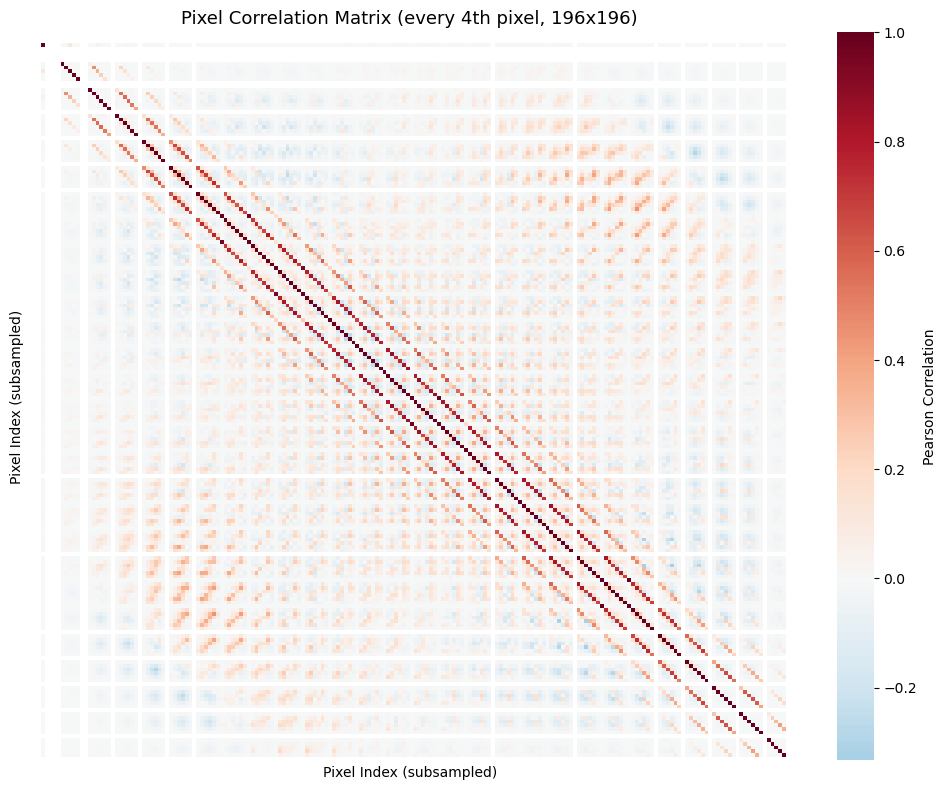

Correlation stats (upper triangle):
  Mean: nan
  Std:  nan
  Max:  nan
  % > 0.5: 0.9%


In [10]:
# Subsample every 4th pixel for tractability: 784 -> 196 pixels
subsample_idx = np.arange(0, 784, 4)
train_sub = train_flat[:, subsample_idx]

corr_matrix = np.corrcoef(train_sub.T)  # (196, 196)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, ax=ax, cmap="RdBu_r", center=0,
            xticklabels=False, yticklabels=False,
            cbar_kws={"label": "Pearson Correlation"})
ax.set_title("Pixel Correlation Matrix (every 4th pixel, 196x196)", fontsize=13)
ax.set_xlabel("Pixel Index (subsampled)")
ax.set_ylabel("Pixel Index (subsampled)")
plt.tight_layout()
plt.show()

# Summary stats
upper_tri = corr_matrix[np.triu_indices_from(corr_matrix, k=1)]
print(f"Correlation stats (upper triangle):")
print(f"  Mean: {upper_tri.mean():.4f}")
print(f"  Std:  {upper_tri.std():.4f}")
print(f"  Max:  {upper_tri.max():.4f}")
print(f"  % > 0.5: {(upper_tri > 0.5).sum() / len(upper_tri) * 100:.1f}%")

## 7. PCA Analysis

  90% variance: 87 components
  95% variance: 154 components
  99% variance: 201 components


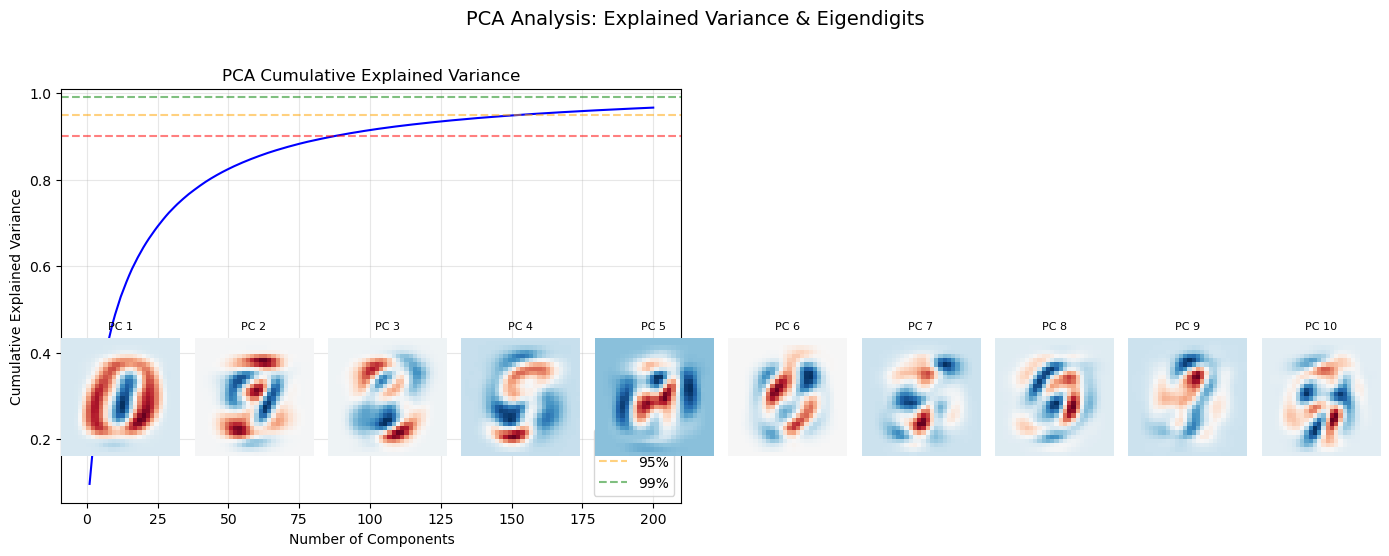

In [11]:
pca = PCA(n_components=200, random_state=42)
pca.fit(train_flat)

cumvar = np.cumsum(pca.explained_variance_ratio_)

# Find components needed for 90%, 95%, 99%
for threshold in [0.90, 0.95, 0.99]:
    n_comp = np.searchsorted(cumvar, threshold) + 1
    print(f"  {threshold*100:.0f}% variance: {n_comp} components")

# Plot cumulative explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(cumvar) + 1), cumvar, "b-", linewidth=1.5)
axes[0].axhline(y=0.90, color="r", linestyle="--", alpha=0.5, label="90%")
axes[0].axhline(y=0.95, color="orange", linestyle="--", alpha=0.5, label="95%")
axes[0].axhline(y=0.99, color="green", linestyle="--", alpha=0.5, label="99%")
axes[0].set_xlabel("Number of Components")
axes[0].set_ylabel("Cumulative Explained Variance")
axes[0].set_title("PCA Cumulative Explained Variance")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Eigendigits: first 10 principal components as 28x28 images
for i in range(10):
    ax = fig.add_subplot(2, 10, 11 + i)
    eigendigit = pca.components_[i].reshape(28, 28)
    ax.imshow(eigendigit, cmap="RdBu_r")
    ax.set_title(f"PC {i+1}", fontsize=8)
    ax.axis("off")

# Remove unused right subplot
axes[1].remove()

fig.suptitle("PCA Analysis: Explained Variance & Eigendigits", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. t-SNE Projection

Running t-SNE on 8000 samples (PCA 784 -> 50 -> 2)...
Done.


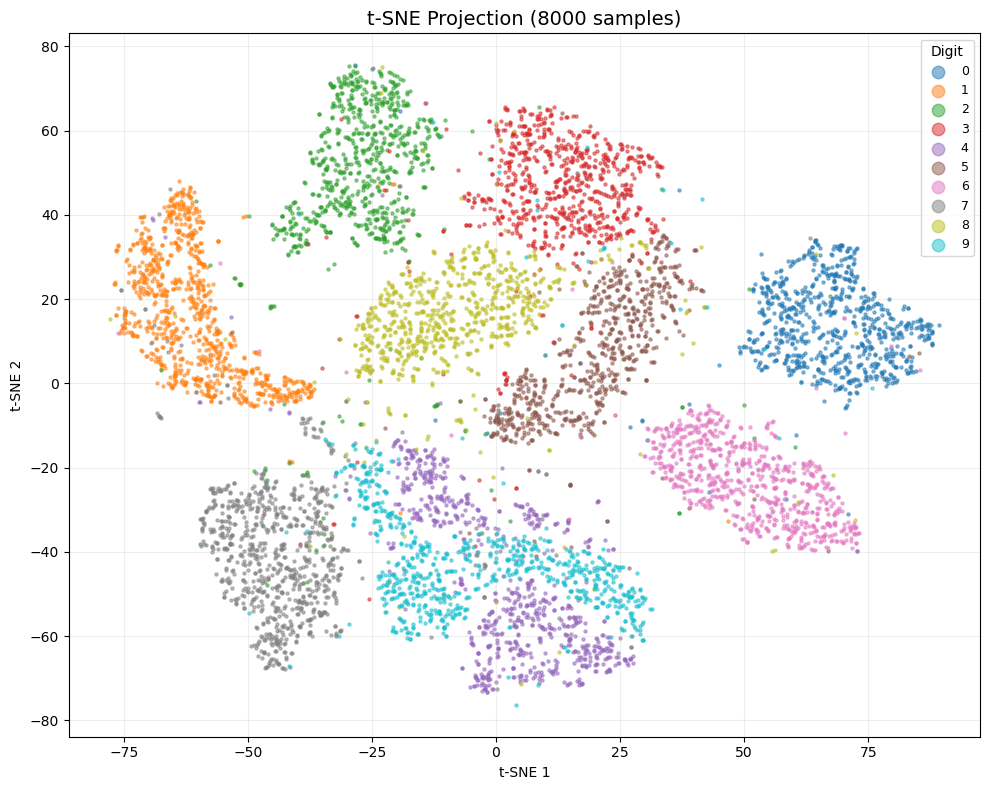

In [13]:
N_SAMPLES = 8000
rng = np.random.RandomState(42)
subset_idx = rng.choice(len(train_flat), size=N_SAMPLES, replace=False)
X_subset = train_flat[subset_idx]
y_subset = train_labels[subset_idx]

# PCA to 50 dims first (standard speedup)
pca_50 = PCA(n_components=50, random_state=42)
X_pca50 = pca_50.fit_transform(X_subset)

print(f"Running t-SNE on {N_SAMPLES} samples (PCA 784 -> 50 -> 2)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca50)
print("Done.")

fig, ax = plt.subplots(figsize=(10, 8))
for digit in range(10):
    mask = y_subset == digit
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=5, alpha=0.5, label=str(digit))

ax.set_title(f"t-SNE Projection ({N_SAMPLES} samples)", fontsize=14)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(title="Digit", markerscale=4, fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 9. UMAP Projection

Running UMAP on 8000 samples...


/Users/morgancooper/miniconda3/envs/msds686/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Done.


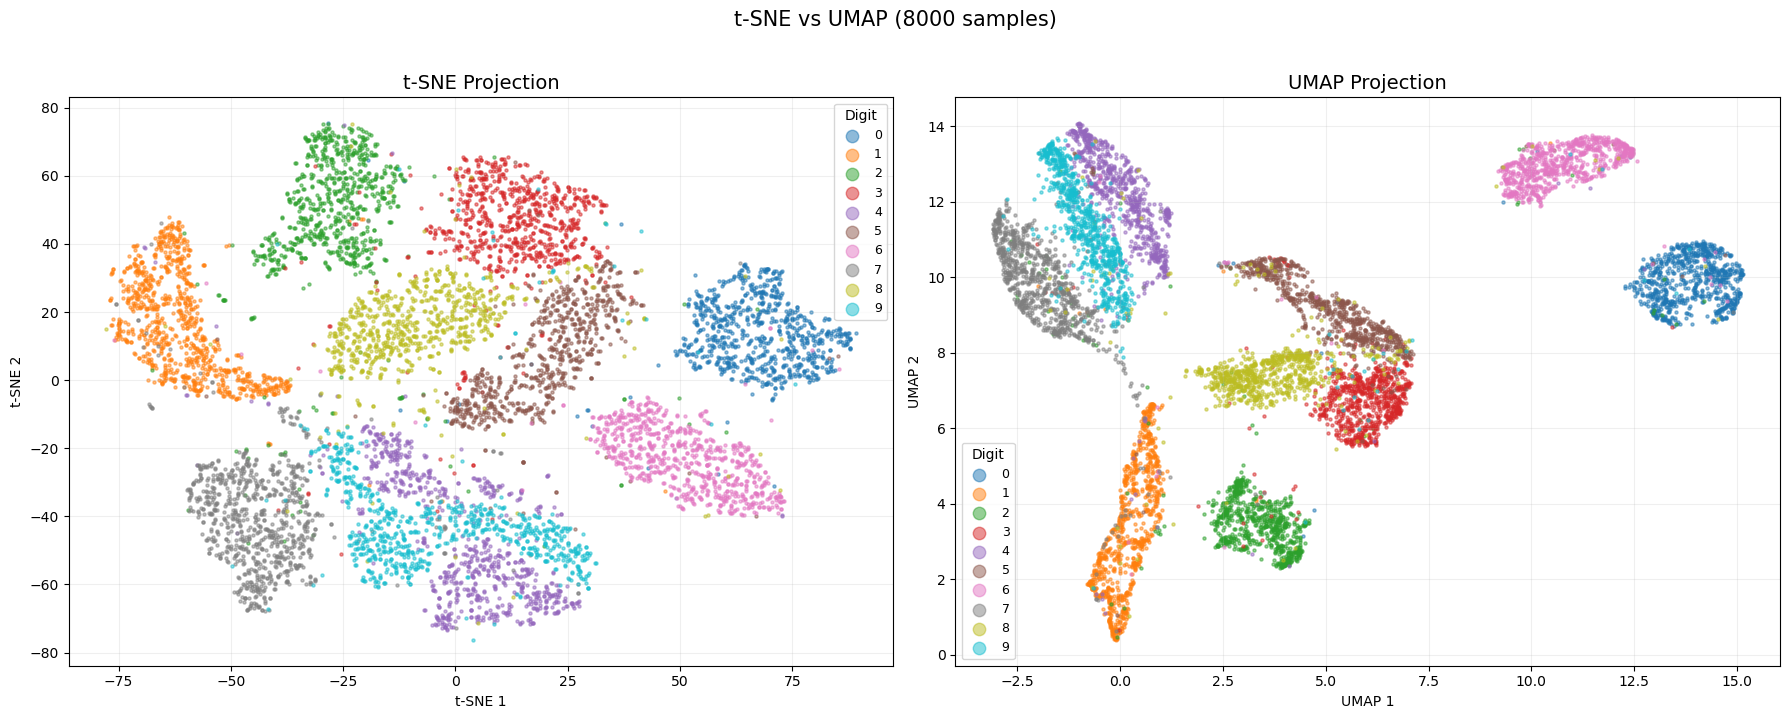

In [14]:
print(f"Running UMAP on {N_SAMPLES} samples...")
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap = reducer.fit_transform(X_subset)
print("Done.")

# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, X_proj, title in [
    (axes[0], X_tsne, "t-SNE"),
    (axes[1], X_umap, "UMAP"),
]:
    for digit in range(10):
        mask = y_subset == digit
        ax.scatter(X_proj[mask, 0], X_proj[mask, 1], s=5, alpha=0.5, label=str(digit))
    ax.set_title(f"{title} Projection", fontsize=14)
    ax.set_xlabel(f"{title} 1")
    ax.set_ylabel(f"{title} 2")
    ax.legend(title="Digit", markerscale=4, fontsize=9)
    ax.grid(True, alpha=0.2)

fig.suptitle(f"t-SNE vs UMAP ({N_SAMPLES} samples)", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 10. Outlier Detection (Distance to Centroid)

/var/folders/by/24jm3kg56bqc__yntqtthmyw0000gn/T/ipykernel_70397/843563561.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(dist_by_class, labels=[str(d) for d in range(10)], patch_artist=True)


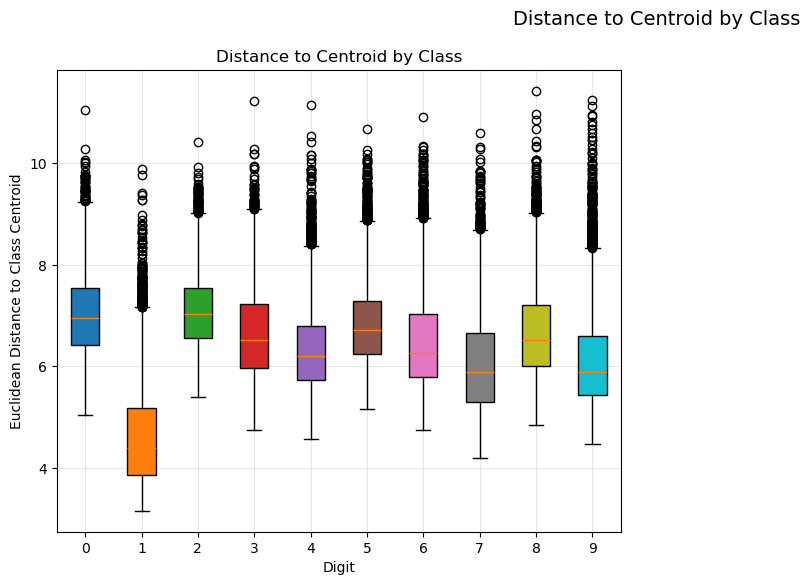

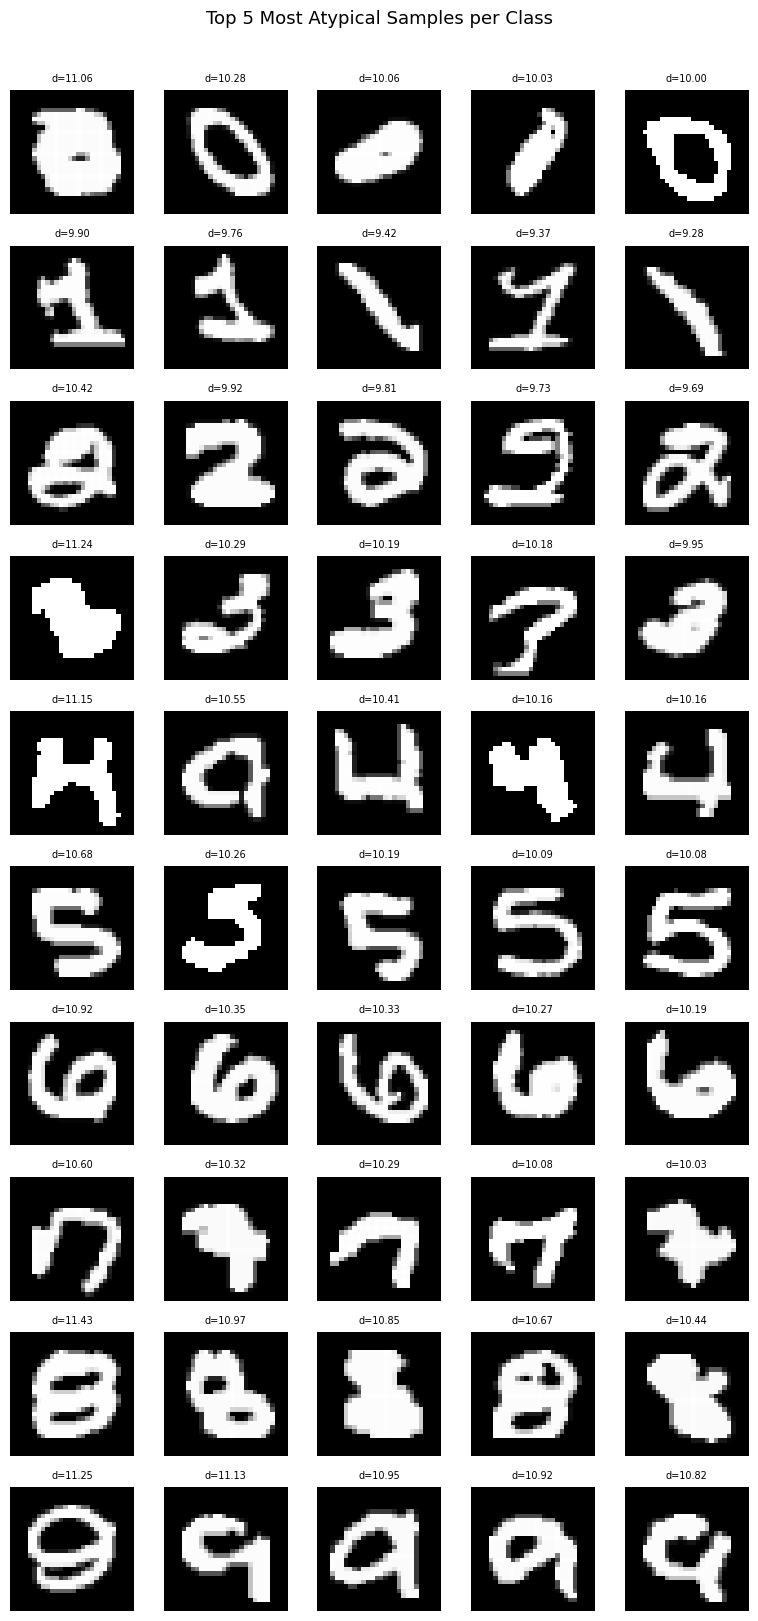

In [15]:
# Compute per-class centroids in pixel space
centroids = np.zeros((10, 784))
for digit in range(10):
    centroids[digit] = train_flat[train_labels == digit].mean(axis=0)

# Distance of each sample to its class centroid
distances = np.zeros(len(train_flat))
for i in range(len(train_flat)):
    distances[i] = np.linalg.norm(train_flat[i] - centroids[train_labels[i]])

# Box plot of distances per class
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

dist_by_class = [distances[train_labels == d] for d in range(10)]
bp = axes[0].boxplot(dist_by_class, labels=[str(d) for d in range(10)], patch_artist=True)
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(plt.cm.tab10(i))
axes[0].set_xlabel("Digit")
axes[0].set_ylabel("Euclidean Distance to Class Centroid")
axes[0].set_title("Distance to Centroid by Class")
axes[0].grid(True, alpha=0.3)

# Show top 5 most atypical samples per class
N_OUTLIERS = 5
axes[1].axis("off")
axes[1].remove()

fig2, axes2 = plt.subplots(10, N_OUTLIERS, figsize=(8, 16))

for digit in range(10):
    mask = train_labels == digit
    class_distances = distances[mask]
    class_indices = np.where(mask)[0]
    top_outlier_idx = class_indices[np.argsort(class_distances)[-N_OUTLIERS:][::-1]]

    for col, idx in enumerate(top_outlier_idx):
        axes2[digit, col].imshow(train_images[idx], cmap="gray")
        axes2[digit, col].set_title(f"d={distances[idx]:.2f}", fontsize=7)
        axes2[digit, col].axis("off")

    axes2[digit, 0].set_ylabel(str(digit), fontsize=12, rotation=0, labelpad=15, va="center")
    axes2[digit, 0].yaxis.set_visible(True)
    axes2[digit, 0].tick_params(left=False, labelleft=False)

fig.suptitle("Distance to Centroid by Class", fontsize=14)
plt.tight_layout()

fig2.suptitle(f"Top {N_OUTLIERS} Most Atypical Samples per Class", fontsize=13, y=1.01)
fig2.tight_layout()
plt.show()

## Summary

**Key findings from this EDA:**

- **Class balance:** MNIST is well-balanced (max/min ratio close to 1.2), so no resampling or weighted loss is needed.
- **Sparsity:** ~81% of pixels are exactly 0 (black background). The data lives in a sparse, low-rank subspace.
- **Intrinsic dimensionality:** PCA shows ~87 components capture 95% of variance out of 784 total. The effective dimensionality is much lower than the pixel count.
- **Cluster structure:** Both t-SNE and UMAP reveal clear, well-separated digit clusters with some expected overlap (4/9, 3/5, 7/9).
- **Per-class variation:** Std images show highest variation in stroke regions (loops, angles, crossbars), not in the centers of strokes.
- **Outliers:** Distance-to-centroid reveals genuinely unusual writing styles and potential labeling ambiguities.

See `README.md` for full methodology details and citations for each technique.